In [1]:
import os, sys

sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
import jax

from neurolib.utils.loadData import Dataset
from neurolib2.models.wilsonCowanModel.wilsonCowanModel import WilsonCowan

In [2]:
import diffrax

In [3]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [4]:
ds = Dataset("hcp")

In [5]:
indices = slice(0, 50)

C_small = ds.Cmat[indices, indices]
D_small = ds.Dmat[indices, indices]

In [6]:
model = WilsonCowan(state=None, dt=0.25, fiber_length_matrix=ds.Dmat, fiber_density_matrix=ds.Cmat)

In [7]:
model.unique_delays

Array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
       11. , 11.5, 12. , 12.5], dtype=float32)

In [8]:
# model.simulation_params["adjoint"] = diffrax.ForwardMode()

In [9]:
ts, ys = model.simulate(duration=1.0)

<class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'> (4, 4, 80)


In [13]:
ts, ys = model.simulate(duration=1.0)

In [10]:
ts, ys = model.simulate(duration=10.0)

<class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'> (40, 4, 80)


In [11]:
ys.shape

(40, 4, 80)

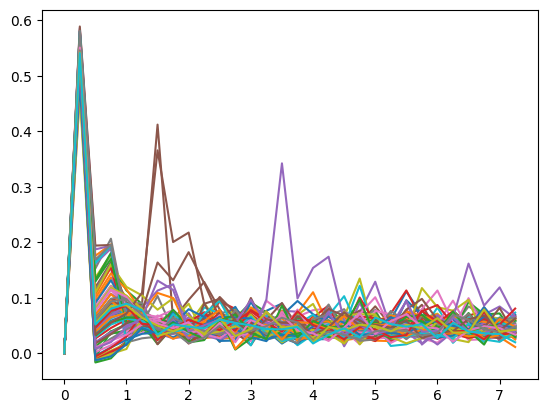

In [12]:
plt.plot(ts[:30], ys[:30, 0, :])

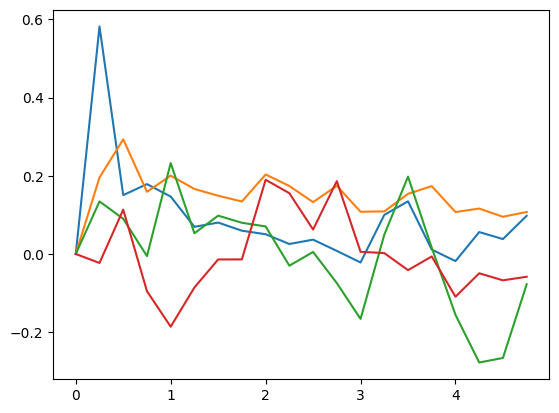

In [ ]:
plt.plot(ts[:20], ys[:20, :, 0])